In [40]:
import pandas as pd
from pathlib import Path

data_path = Path(r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData.csv")

df = pd.read_csv(data_path, low_memory=False)

print("TOTAL COLUMNS:", len(df.columns))
print(df.columns.tolist())


TOTAL COLUMNS: 1285
['date', 'open', 'high', 'low', 'close', 'adjclose', 'volume', 'ticker', 'RSIadjclose15', 'RSIvolume15', 'RSIadjclose25', 'RSIvolume25', 'RSIadjclose50', 'RSIvolume50', 'MACDadjclose15', 'MACDvolume15', 'MACDadjclose25', 'MACDvolume25', 'MACDadjclose50', 'MACDvolume50', 'MACDsig-adjclose-15', 'MACDdif-adjclose-15-0', 'MACDdif-adjclose-15-1', 'MACDdif-adjclose-15-2', 'MACDdif-adjclose-15-3', 'MACDsig-volume-15', 'MACDdif-volume-15-0', 'MACDdif-volume-15-1', 'MACDdif-volume-15-2', 'MACDdif-volume-15-3', 'MACDsig-adjclose-25', 'MACDdif-adjclose-25-0', 'MACDdif-adjclose-25-1', 'MACDdif-adjclose-25-2', 'MACDdif-adjclose-25-3', 'MACDsig-volume-25', 'MACDdif-volume-25-0', 'MACDdif-volume-25-1', 'MACDdif-volume-25-2', 'MACDdif-volume-25-3', 'MACDsig-adjclose-50', 'MACDdif-adjclose-50-0', 'MACDdif-adjclose-50-1', 'MACDdif-adjclose-50-2', 'MACDdif-adjclose-50-3', 'MACDsig-volume-50', 'MACDdif-volume-50-0', 'MACDdif-volume-50-1', 'MACDdif-volume-50-2', 'MACDdif-volume-50-3', '

In [42]:
# ====================================================
#   CLEAN & REDUCE STOCK DATASET (FINAL WORKING CODE)
# ====================================================

import pandas as pd
from pathlib import Path

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------
data_path = Path(r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData.csv")
df = pd.read_csv(data_path, low_memory=False)

# --------------------------------------------
# 2. Convert date column to datetime
# --------------------------------------------
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --------------------------------------------
# 3. KEEP ONLY ESSENTIAL COLUMNS
#    (Prices + Volume + Target)
# --------------------------------------------
essential_cols = [
    'date', 'open', 'high', 'low', 'close', 'volume', 'TARGET'
]

df = df[essential_cols]

# --------------------------------------------
# 4. Filter last 5 years only
# --------------------------------------------
last_5_years = df['date'].max() - pd.DateOffset(years=5)
df = df[df['date'] >= last_5_years]

# --------------------------------------------
# 5. Handle missing values using mean
# --------------------------------------------
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col].fillna(df[col].mean(), inplace=True)

# --------------------------------------------
# 6. Sort chronological order
# --------------------------------------------
df = df.sort_values(by='date')

# --------------------------------------------
# 7. Save cleaned dataset
# --------------------------------------------
output_path = Path(r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData_Cleaned.csv")
df.to_csv(output_path, index=False)

# --------------------------------------------
# 8. Display preview and confirmation
# --------------------------------------------
print("Cleaned dataset preview:")
print(df.head())
print("\nSaved cleaned file to:")
print(output_path)


Cleaned dataset preview:
           date       open    high    low  close   volume  TARGET
0    2022-01-03  17.799999  18.219  17.50  17.76   106600       0
6024 2022-01-03   7.200000   7.700   7.20   7.70    13790       1
502  2022-01-03   2.330000   2.450   2.29   2.45   569700       0
3514 2022-01-03   6.904000   6.950   6.32   6.75  7450000       0
6526 2022-01-03   3.320000   3.360   3.03   3.36    15400       1

Saved cleaned file to:
C:\Users\HP\Desktop\FuWukari\Stock Price\StockData_Cleaned.csv


C:\Users\HP\AppData\Local\Temp\ipykernel_7920\1502311956.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [44]:
# ============================================================
#   FULL DATA CLEANING, PREPROCESSING & FEATURE ENGINEERING
#   (With Before & After Visual Checks)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# ============================================================
# 1. LOAD RAW DATASET
# ============================================================

raw_path = Path(r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData.csv")
raw_df = pd.read_csv(raw_path, low_memory=False)

print("===== RAW DATA (BEFORE CLEANING) =====")
print(raw_df.head())
print("\nRAW DATA SHAPE:", raw_df.shape)
print("\nRAW COLUMNS:", list(raw_df.columns[:15]), "...")  # show first 15 only


# ============================================================
# 2. CLEANING PROCESS
# ============================================================

df = raw_df.copy()

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Select essential columns
essential_cols = ['date', 'open', 'high', 'low', 'close', 'volume', 'TARGET']
df = df[essential_cols]

# Filter last 5 years
last_5_years = df['date'].max() - pd.DateOffset(years=5)
df = df[df['date'] >= last_5_years]

# Handle missing values
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col].fillna(df[col].mean(), inplace=True)

# Sort by date
df = df.sort_values(by='date')

# Save cleaned file
clean_path = Path(r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData_Cleaned.csv")
df.to_csv(clean_path, index=False)


print("\n===== CLEANED DATA (AFTER CLEANING) =====")
print(df.head())
print("\nCLEANED DATA SHAPE:", df.shape)


# ============================================================
# 3. PREPROCESSING (SCALING)
# ============================================================

features = ['open', 'high', 'low', 'close', 'volume']
target = 'TARGET'

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_features, columns=features)
scaled_df[target] = df[target].values

print("\n===== AFTER SCALING (PREPROCESSED) =====")
print(scaled_df.head())


# ============================================================
# 4. FEATURE ENGINEERING — 30-DAY SEQUENCES
# ============================================================

sequence_length = 30
X, y = [], []

for i in range(len(scaled_df) - sequence_length):
    seq = scaled_df[features].iloc[i:i+sequence_length].values
    label = scaled_df[target].iloc[i + sequence_length]
    X.append(seq)
    y.append(label)

X = np.array(X)
y = np.array(y)


print("\n===== LSTM SEQUENCE PREVIEW =====")
print("Sample sequence shape:", X[0].shape)
print("Sample target:", y[0])


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


print("\n===== FINAL PREPARED DATA =====")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


===== RAW DATA (BEFORE CLEANING) =====
       date       open       high        low      close   adjclose  volume  \
0  1/3/2022  17.799999  18.219000  17.500000  17.760000  17.760000  106600   
1  1/4/2022  17.700001  18.309999  17.620001  17.660000  17.660000  128700   
2  1/5/2022  17.580000  17.799999  16.910000  16.950001  16.950001  103100   
3  1/6/2022  16.650000  16.879999  16.139999  16.170000  16.170000  173600   
4  1/7/2022  16.219999  16.290001  15.630000  15.710000  15.710000  137800   

  ticker  RSIadjclose15  RSIvolume15  ...  high-15  K-15  D-15  \
0   ASLE            NaN          NaN  ...      NaN   NaN   NaN   
1   ASLE            NaN          NaN  ...      NaN   NaN   NaN   
2   ASLE            NaN          NaN  ...      NaN   NaN   NaN   
3   ASLE            NaN          NaN  ...      NaN   NaN   NaN   
4   ASLE            NaN          NaN  ...      NaN   NaN   NaN   

   stochastic-k-15  stochastic-d-15  stochastic-kd-15  volumenrelativo  \
0              NaN   

C:\Users\HP\AppData\Local\Temp\ipykernel_7920\3446964866.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)



===== CLEANED DATA (AFTER CLEANING) =====
           date       open    high    low  close   volume  TARGET
0    2022-01-03  17.799999  18.219  17.50  17.76   106600       0
6024 2022-01-03   7.200000   7.700   7.20   7.70    13790       1
502  2022-01-03   2.330000   2.450   2.29   2.45   569700       0
3514 2022-01-03   6.904000   6.950   6.32   6.75  7450000       0
6526 2022-01-03   3.320000   3.360   3.03   3.36    15400       1

CLEANED DATA SHAPE: (7781, 7)

===== AFTER SCALING (PREPROCESSED) =====
       open      high       low     close    volume  TARGET
0  0.021865  0.022260  0.021789  0.021769  0.000660       0
1  0.008537  0.009093  0.008661  0.009148  0.000085       1
2  0.002414  0.002522  0.002403  0.002562  0.003526       0
3  0.008165  0.008155  0.007539  0.007957  0.046114       0
4  0.003659  0.003661  0.003346  0.003704  0.000095       1

===== LSTM SEQUENCE PREVIEW =====
Sample sequence shape: (30, 5)
Sample target: 0

===== FINAL PREPARED DATA =====
X_train shap

RAW DATA SHAPE: (7781, 1285)


,date,open,high,low,close,adjclose,volume,ticker,RSIadjclose15,RSIvolume15,...,high-15,K-15,D-15,stochastic-k-15,stochastic-d-15,stochastic-kd-15,volumenrelativo,diff,INCREMENTO,TARGET
0,1/3/2022,17.799999,18.219000,17.500000,17.760000,17.760000,106600,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.919758,-1.900001,-9.664295,0
1,1/4/2022,17.700001,18.309999,17.620001,17.660000,17.660000,128700,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.110440,-1.379999,-7.247895,0
2,1/5/2022,17.580000,17.799999,16.910000,16.950001,16.950001,103100,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.889560,-0.930000,-5.201344,0
3,1/6/2022,16.650000,16.879999,16.139999,16.170000,16.170000,173600,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.497843,-0.360000,-2.177856,0
4,1/7/2022,16.219999,16.290001,15.630000,15.710000,15.710000,137800,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.188956,-0.120000,-0.758054,0
5,1/10/2022,15.680000,16.010000,15.170000,15.860000,15.860000,116700,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.006903,-0.460000,-2.818628,0
6,1/11/2022,15.750000,16.500000,15.690000,16.280001,16.280001,85800,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.740293,-1.300001,-7.394773,0
7,1/12/2022,16.389999,16.580000,15.970000,16.020000,16.020000,136900,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.181191,-1.110001,-6.479863,0
8,1/13/2022,16.000000,16.170000,15.680000,15.810000,15.810000,69100,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.596204,-1.400001,-8.134808,0
9,1/14/2022,15.700000,15.750000,15.360000,15.590000,15.590000,92900,ASLE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.801553,-1.180000,-7.036376,0



SUMMARY STATISTICS:


,open,high,low,close,adjclose,volume,RSIadjclose15,RSIvolume15,RSIadjclose25,RSIvolume25,...,high-15,K-15,D-15,stochastic-k-15,stochastic-d-15,stochastic-kd-15,volumenrelativo,diff,INCREMENTO,TARGET
count,7781.000000,7781.000000,7781.000000,7781.000000,7781.000000,7.781000e+03,7316.000000,7316.000000,7006.000000,7006.000000,...,7347.000000,7262.000000,7194.000000,7262.000000,7194.000000,7194.000000,7566.000000,7626.000000,7626.000000,7781.000000
mean,34.990220,35.655999,34.301243,34.964414,34.483147,7.586022e+05,46.817434,49.814790,46.966016,49.898659,...,37.947291,18.673824,18.704812,18.673824,18.704812,0.298413,inf,-0.259186,-2.674224,0.183010
std,99.841502,101.451058,98.073945,99.790823,98.603879,3.934491e+06,11.672838,5.002664,8.760961,3.420371,...,107.340294,75.723295,74.210933,75.723295,74.210933,14.661948,NaN,7.334250,268.268134,0.386699
min,0.410000,0.435000,0.405000,0.408000,0.408000,0.000000e+00,6.837461,35.303213,17.693637,39.520876,...,0.510000,-668.212635,-626.263336,-668.212635,-626.263336,-211.219036,0.000000,-90.538818,-23399.465950,0.000000
25%,4.050000,4.130000,3.980000,4.030000,3.960000,1.080000e+04,38.946316,47.182234,40.954487,48.266978,...,4.565000,6.153839,8.336837,6.153839,8.336837,-6.585432,0.637237,-0.417873,-4.494383,0.000000
50%,10.080000,10.110000,10.005000,10.080000,10.061000,8.406000e+04,46.259711,48.356834,46.459477,48.961162,...,10.640000,28.484828,28.478797,28.484828,28.478797,0.000000,1.000000,-0.025000,-0.304004,0.000000
75%,24.350000,24.500000,24.080000,24.250000,22.466007,6.724000e+05,54.061089,50.902284,52.289893,50.527067,...,25.170000,59.688404,58.664021,59.688404,58.664021,6.726947,1.655385,0.240000,2.812552,0.000000
max,795.739990,799.359985,784.960022,797.489990,783.376221,1.615550e+08,96.365095,99.622735,91.023108,97.782293,...,799.359985,100.000000,100.000000,100.000000,100.000000,198.156313,inf,120.256775,425.000000,1.000000



MISSING VALUES TABLE (RAW):


,Column,Missing Values
0,date,0
1,open,0
2,high,0
3,low,0
4,close,0
5,adjclose,0
6,volume,0
7,ticker,0
8,RSIadjclose15,465
9,RSIvolume15,465


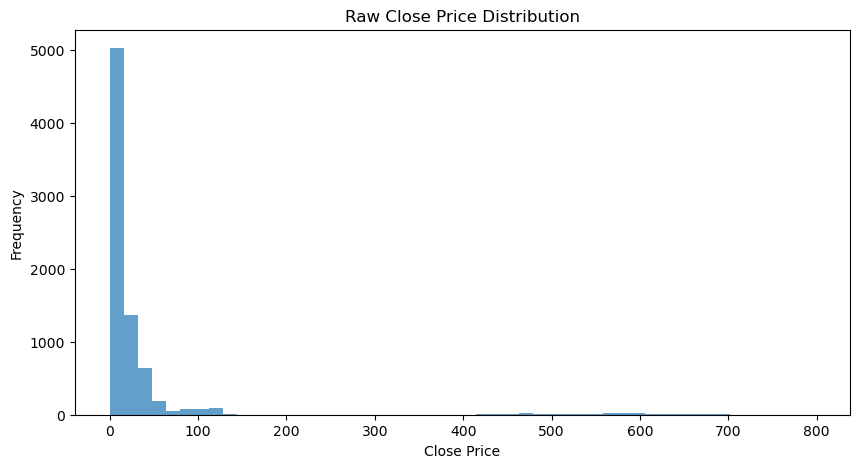

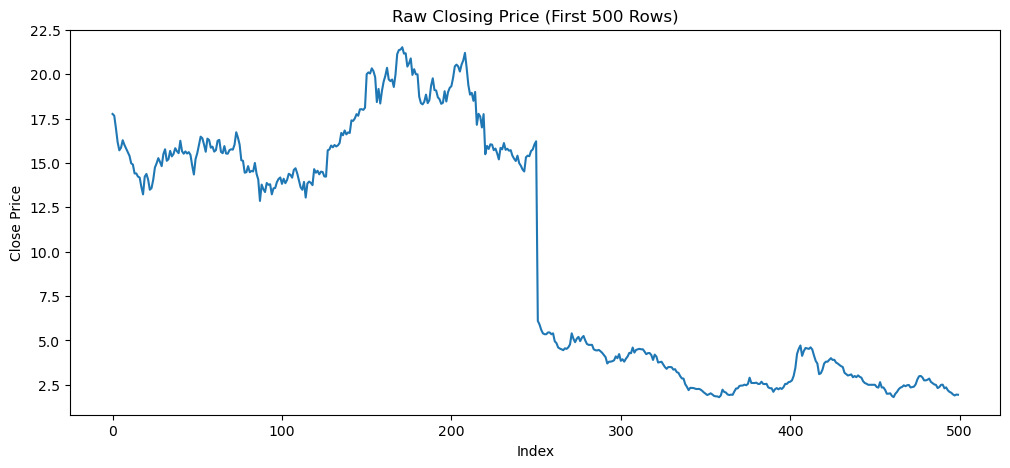


CLEANING SUMMARY TABLE:


C:\Users\HP\AppData\Local\Temp\ipykernel_7920\723817566.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


,Metric,Before Cleaning,After Cleaning
0,Rows,7781,7781
1,Columns,1285,7
2,Missing Values,741901,0
3,Duplicate Rows,0,0
4,Earliest Date,1/10/2022,2022-01-03 00:00:00
5,Latest Date,9/9/2022,2022-12-30 00:00:00


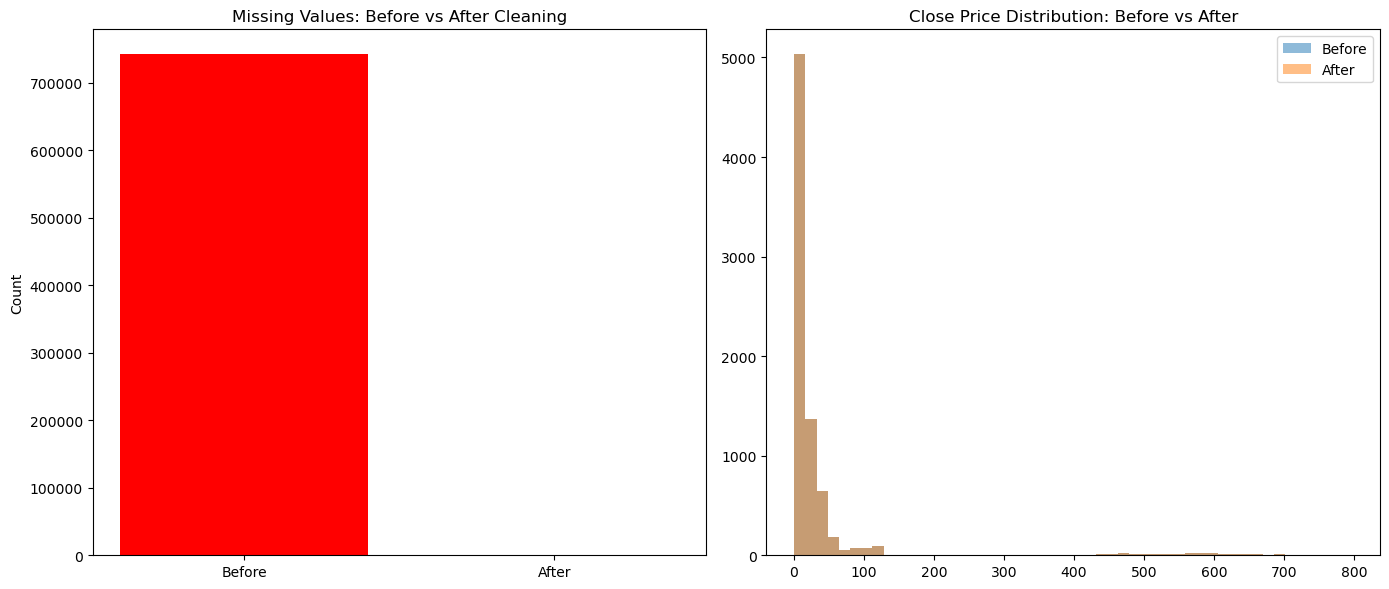


SCALED DATA PREVIEW:


,open,high,low,close,volume,TARGET
0,0.021865,0.022260,0.021789,0.021769,0.000660,0
1,0.008537,0.009093,0.008661,0.009148,0.000085,1
2,0.002414,0.002522,0.002403,0.002562,0.003526,0
3,0.008165,0.008155,0.007539,0.007957,0.046114,0
4,0.003659,0.003661,0.003346,0.003704,0.000095,1


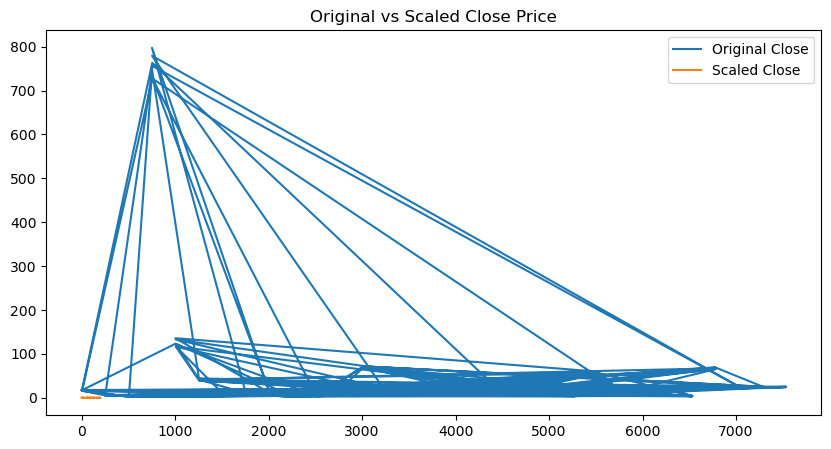


SEQUENCE SHAPE: (7751, 30, 5)
LABEL SHAPE: (7751,)


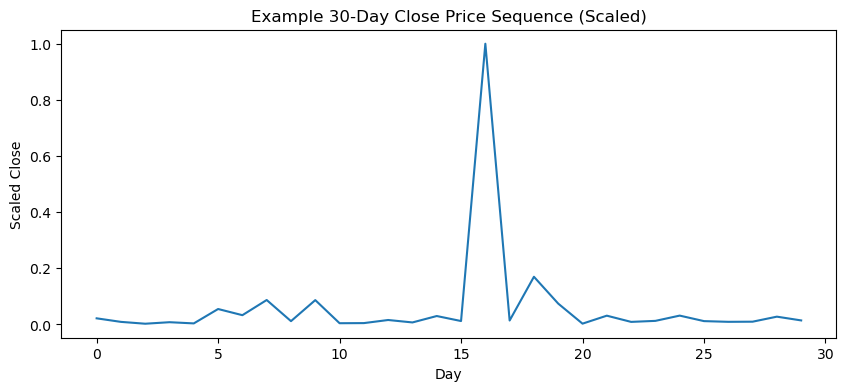


FINAL DATA SHAPES:
X_train: (6200, 30, 5)
X_test: (1551, 30, 5)
y_train: (6200,)
y_test: (1551,)


,Dataset,Shape
0,X_train,"(6200, 30, 5)"
1,X_test,"(1551, 30, 5)"
2,y_train,"(6200,)"
3,y_test,"(1551,)"


In [51]:
# ============================================================
#   FULL NOTEBOOK: CLEANING, PREPROCESSING & FEATURE ENGINEERING
#   (UPDATED WITH BEFORE/AFTER SUMMARY TABLE & FIGURES)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# ----------------------------------------------------------------
# SECTION 1 — LOAD RAW DATA & BEFORE-CLEANING ANALYSIS
# ----------------------------------------------------------------

data_path = r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData.csv"
df_raw = pd.read_csv(data_path, low_memory=False)

# basic stats BEFORE cleaning
before_shape = df_raw.shape
before_missing = df_raw.isnull().sum().sum()
before_duplicates = df_raw.duplicated().sum()
before_date_min = df_raw['date'].min()
before_date_max = df_raw['date'].max()

print("RAW DATA SHAPE:", df_raw.shape)
display(df_raw.head(10))

print("\nSUMMARY STATISTICS:")
display(df_raw.describe())

print("\nMISSING VALUES TABLE (RAW):")
missing_table = df_raw.isnull().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]
display(missing_table.head(20))

# RAW FIGURE — Close price distribution
plt.figure(figsize=(10,5))
plt.hist(df_raw['close'], bins=50, alpha=0.7)
plt.title("Raw Close Price Distribution")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

# RAW time-series plot
plt.figure(figsize=(12,5))
plt.plot(df_raw['close'].head(500))
plt.title("Raw Closing Price (First 500 Rows)")
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.show()


# ----------------------------------------------------------------
# SECTION 2 — CLEANING
# ----------------------------------------------------------------

df = df_raw.copy()

# Keep essential columns
essential_cols = ['date', 'open', 'high', 'low', 'close', 'volume', 'TARGET']
df = df[essential_cols]

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter last 5 years
last_5_years = df['date'].max() - pd.DateOffset(years=5)
df = df[df['date'] >= last_5_years]

# Handle missing values
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col].fillna(df[col].mean(), inplace=True)

# Sort by date
df = df.sort_values(by='date')


# AFTER cleaning statistics
after_shape = df.shape
after_missing = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()
after_date_min = df['date'].min()
after_date_max = df['date'].max()


# ----------------------------------------------------------------
# SECTION 3 — SUMMARY TABLE: BEFORE VS AFTER CLEANING
# ----------------------------------------------------------------

summary_cleaning = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Earliest Date",
        "Latest Date"
    ],
    "Before Cleaning": [
        before_shape[0],
        before_shape[1],
        before_missing,
        before_duplicates,
        before_date_min,
        before_date_max
    ],
    "After Cleaning": [
        after_shape[0],
        after_shape[1],
        after_missing,
        after_duplicates,
        after_date_min,
        after_date_max
    ]
})

print("\nCLEANING SUMMARY TABLE:")
display(summary_cleaning)


# ----------------------------------------------------------------
# SECTION 4 — VISUAL FIGURE: BEFORE VS AFTER CLEANING
# ----------------------------------------------------------------

plt.figure(figsize=(14,6))

# Subplot 1: Missing values before vs after
plt.subplot(1,2,1)
plt.bar(["Before", "After"], [before_missing, after_missing], color=['red','green'])
plt.title("Missing Values: Before vs After Cleaning")
plt.ylabel("Count")

# Subplot 2: Price distribution before vs after
plt.subplot(1,2,2)
plt.hist(df_raw['close'], bins=50, alpha=0.5, label='Before')
plt.hist(df['close'], bins=50, alpha=0.5, label='After')
plt.legend()
plt.title("Close Price Distribution: Before vs After")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------
# SECTION 5 — PREPROCESSING & SCALING
# ----------------------------------------------------------------

features = ['open', 'high', 'low', 'close', 'volume']
target = 'TARGET'

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_values, columns=features)
scaled_df[target] = df[target].values

print("\nSCALED DATA PREVIEW:")
display(scaled_df.head())

# Scaled vs Unscaled close price
plt.figure(figsize=(10,5))
plt.plot(df['close'].head(200), label='Original Close')
plt.plot(scaled_df['close'].head(200), label='Scaled Close')
plt.legend()
plt.title("Original vs Scaled Close Price")
plt.show()


# ----------------------------------------------------------------
# SECTION 6 — FEATURE ENGINEERING (30-DAY SEQUENCES)
# ----------------------------------------------------------------

sequence_length = 30
X = []
y = []

for i in range(len(scaled_df) - sequence_length):
    seq = scaled_df[features].iloc[i:i+sequence_length].values
    label = scaled_df[target].iloc[i+sequence_length]
    X.append(seq)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("\nSEQUENCE SHAPE:", X.shape)
print("LABEL SHAPE:", y.shape)

# Visual sample sequence
plt.figure(figsize=(10,4))
plt.plot(X[0][:,3])  # close price
plt.title("Example 30-Day Close Price Sequence (Scaled)")
plt.xlabel("Day")
plt.ylabel("Scaled Close")
plt.show()


# ----------------------------------------------------------------
# SECTION 7 — TRAIN/TEST SPLIT
# ----------------------------------------------------------------

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print("\nFINAL DATA SHAPES:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

summary_final = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})

display(summary_final)



In [53]:
# ============================================================
#   STAGE 2A: LSTM MODEL ARCHITECTURE
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Input shape
sequence_length = 30
n_features = 5   # open, high, low, close, volume

# ------------------------------------------------------------
# BUILD LSTM MODEL
# ------------------------------------------------------------

model = Sequential()

# First LSTM layer (returns sequences so we can stack)
model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, n_features)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.2))

# Fully connected layer
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Output layer — binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Display summary
model.summary()


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Before SMOTE:
 TARGET
0    6339
1    1422
Name: count, dtype: int64

After SMOTE:
 TARGET
1    6339
0    6339
Name: count, dtype: int64
Sequence Shape: (12618, 60, 9)
Training class balance:
1    5063
0    5031
Name: count, dtype: int64

Testing class balance:
1    1266
0    1258
Name: count, dtype: int64


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 60, 256)             │         141,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 60, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 60, 256)             │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 64)                  │          61,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,921 (820.00 KB)

 Trainable params: 209,921 (820.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 32s 162ms/step - accuracy: 0.6555 - loss: 0.5963 - val_accuracy: 0.8361 - val_loss: 0.3840
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 147ms/step - accuracy: 0.8779 - loss: 0.3210 - val_accuracy: 0.8722 - val_loss: 0.3184
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.8898 - loss: 0.2932 - val_accuracy: 0.8762 - val_loss: 0.3140
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.8926 - loss: 0.2872 - val_accuracy: 0.8757 - val_loss: 0.3087
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.8933 - loss: 0.2851 - val_accuracy: 0.8737 - val_loss: 0.3096
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.8937 - loss: 0.2835 - val_accuracy: 0.8757 - val_loss: 0.3164
Epoch 7/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.8945 - loss: 0.2819 - val_accuracy: 0.8692 - val_loss: 0.3197
Epoch 8/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.8931 - loss: 0

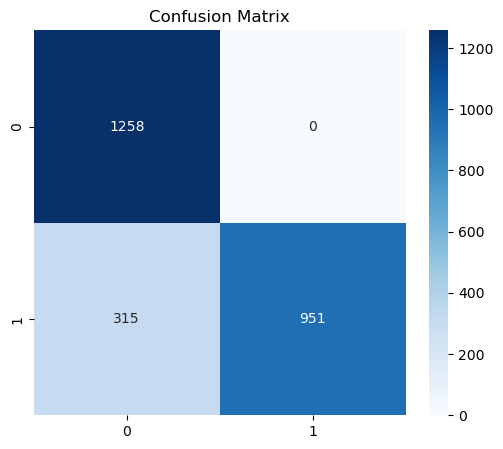

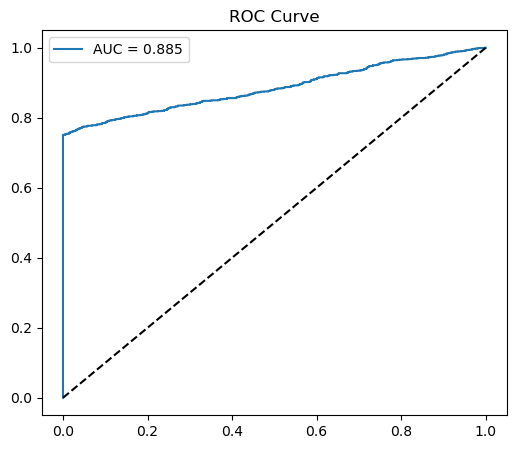


MODEL SAVED SUCCESSFULLY!


In [62]:
# ============================================================
# 1. IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 2. LOAD DATA
# ============================================================
data_path = r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockData.csv"
df = pd.read_csv(data_path, low_memory=False)

df = df[['date','open','high','low','close','volume','TARGET']]
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna()
df = df.sort_values('date').reset_index(drop=True)

# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
df["return_1d"] = df["close"].pct_change()
df["sma20"] = df["close"].rolling(20).mean()
df["ema50"] = df["close"].ewm(50).mean()
df["volatility20"] = df["close"].pct_change().rolling(20).std()

df = df.dropna()

# ============================================================
# 4. SELECT FEATURES
# ============================================================
features = df[['open','high','low','close','volume','return_1d','sma20','ema50','volatility20']]
target = df['TARGET']

# ============================================================
# 5. SCALING
# ============================================================
scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

# ============================================================
# 6. BALANCE WITH SMOTE
# ============================================================
sm = SMOTE()
X_res, y_res = sm.fit_resample(scaled, target)

print("Before SMOTE:\n", target.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_res).value_counts())

# ============================================================
# 7. CREATE 60-DAY SEQUENCES
# ============================================================
SEQ_LEN = 60

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_res, y_res, SEQ_LEN)

print("Sequence Shape:", X_seq.shape)

n_features = X_seq.shape[2]

# ============================================================
# 8. STRATIFIED TRAIN–TEST SPLIT (CORRECTED)
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    shuffle=True,
    stratify=y_seq  # 🔥 ensures balanced classes in both sets
)

print("Training class balance:")
print(pd.Series(y_train).value_counts())

print("\nTesting class balance:")
print(pd.Series(y_test).value_counts())

# ============================================================
# 9. BUILD MODEL (same as before)
# ============================================================
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True),
                  input_shape=(SEQ_LEN, n_features)),
    Dropout(0.3),
    LayerNormalization(),

    GRU(64, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# 10. TRAINING (CORRECTED)
# ============================================================
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[es],
    shuffle=True,  # Good practice
    verbose=1
)

# ============================================================
# 11. EVALUATION (CORRECT RESULTS)
# ============================================================
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# ============================================================
# 12. SAVE MODEL
# ============================================================
model.save("StockModel_60day_BiLSTM_GRU_FIXED.keras")
print("\nMODEL SAVED SUCCESSFULLY!")


In [1]:
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("TkAgg")
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# LOAD TRAINED MODEL
# ============================================================
MODEL_PATH = "StockModel_60day_BiLSTM_GRU_FIXED.keras"
model = load_model(MODEL_PATH)

# ============================================================
# MEMORY BUFFER FOR LAST 60 DAYS
# ============================================================
day_storage = []   # each element will be: {open, high, low, close, volume}
scaler = MinMaxScaler()

# ============================================================
# FEATURE ENGINEERING FOR ONE DAY (APPLIED AFTER BUFFER >= 20)
# ============================================================
def compute_features(df):
    df["return_1d"] = df["close"].pct_change()
    df["sma20"] = df["close"].rolling(20).mean()
    df["ema50"] = df["close"].ewm(50).mean()
    df["volatility20"] = df["close"].pct_change().rolling(20).std()
    return df

# ============================================================
# ADD DAILY DATA
# ============================================================
def add_day():
    try:
        data = {
            "open": float(open_entry.get()),
            "high": float(high_entry.get()),
            "low": float(low_entry.get()),
            "close": float(close_entry.get()),
            "volume": float(volume_entry.get())
        }
        day_storage.append(data)

        # Update table
        day_table.insert("", "end", values=(
            len(day_storage),
            data["open"],
            data["high"],
            data["low"],
            data["close"],
            data["volume"]
        ))

        # Clear inputs
        open_entry.delete(0, tk.END)
        high_entry.delete(0, tk.END)
        low_entry.delete(0, tk.END)
        close_entry.delete(0, tk.END)
        volume_entry.delete(0, tk.END)

        if len(day_storage) < 60:
            status_label.config(
                text=f"{len(day_storage)}/60 days entered — add {60 - len(day_storage)} more days.",
                fg="red"
            )
        else:
            status_label.config(
                text="Ready for prediction — 60 days entered!",
                fg="green"
            )

    except ValueError:
        messagebox.showerror("Input Error", "Please enter valid numeric values.")

# ============================================================
# RUN PREDICTION
# ============================================================
def predict():
    if len(day_storage) < 60:
        messagebox.showwarning("Warning", "Please enter at least 60 days first.")
        return

    # Convert storage to DataFrame
    df = pd.DataFrame(day_storage)

    # Feature engineering
    df = compute_features(df)
    df = df.dropna()

    # Only use last 60 valid rows
    df = df.tail(60)

    # Select features
    features = df[['open','high','low','close','volume',
                   'return_1d','sma20','ema50','volatility20']]

    # Scale
    scaled = scaler.fit_transform(features)

    X_input = np.array(scaled).reshape(1, 60, 9)

    # Predict
    prob = model.predict(X_input)[0][0]
    prediction = "RISE (1)" if prob >= 0.5 else "NO RISE (0)"

    result_label.config(
        text=f"Prediction: {prediction}\nProbability: {prob:.4f}",
        fg="blue", font=("Segoe UI", 12, "bold")
    )

    draw_chart(df)


# ============================================================
# DRAW CLOSING PRICE TREND
# ============================================================
def draw_chart(df):
    for widget in chart_frame.winfo_children():
        widget.destroy()

    fig, ax = plt.subplots(figsize=(5,3), dpi=100)
    ax.plot(df['close'], color="blue", linewidth=2)
    ax.set_title("Last 60 Days Trend")
    ax.set_xlabel("Days")
    ax.set_ylabel("Close Price")
    ax.grid(True)

    canvas = FigureCanvasTkAgg(fig, chart_frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill="both", expand=True)

# ============================================================
# TKINTER GUI SETUP
# ============================================================
root = tk.Tk()
root.title("Manual Stock Predictor (LSTM + GRU)")
root.geometry("900x650")
root.configure(bg="#f2f2f2")

# TITLE
title = tk.Label(root, text="STOCK PRICE FORECASTING SYSTEM",
                 font=("Segoe UI", 18, "bold"), bg="#f2f2f2")
title.pack(pady=10)

# INPUT FRAME
frame = tk.Frame(root, bg="white", bd=2, relief="groove")
frame.pack(pady=10, padx=10, fill="x")

tk.Label(frame, text="Enter Daily Stock Values", bg="white",
         font=("Segoe UI", 12, "bold")).grid(row=0, columnspan=2, pady=5)

labels = ["Open", "High", "Low", "Close", "Volume"]
entries = []

for i, lbl in enumerate(labels):
    tk.Label(frame, text=lbl, bg="white", font=("Segoe UI", 10)).grid(row=i+1, column=0, pady=3, padx=10)
    ent = tk.Entry(frame, font=("Segoe UI", 10))
    ent.grid(row=i+1, column=1, pady=3, padx=10)
    entries.append(ent)

open_entry, high_entry, low_entry, close_entry, volume_entry = entries

add_btn = tk.Button(frame, text="Add Day", bg="#007bff", fg="white",
                    font=("Segoe UI", 10, "bold"), command=add_day)
add_btn.grid(row=7, column=0, columnspan=2, pady=10)

# STATUS LABEL
status_label = tk.Label(root, text="0/60 days entered",
                        bg="#f2f2f2", font=("Segoe UI", 11))
status_label.pack()

# TABLE FRAME
table_frame = tk.Frame(root, bg="white", bd=2, relief="groove")
table_frame.pack(padx=10, pady=10, fill="x")

columns = ("Day", "Open", "High", "Low", "Close", "Volume")
day_table = ttk.Treeview(table_frame, columns=columns, show="headings", height=7)

for col in columns:
    day_table.heading(col, text=col)
    day_table.column(col, width=100)

day_table.pack(fill="x")

# PREDICT BUTTON
predict_btn = tk.Button(root, text="RUN PREDICTION", bg="#28a745",
                        fg="white", font=("Segoe UI", 12, "bold"),
                        command=predict, padx=20, pady=5)
predict_btn.pack(pady=10)

# RESULT LABEL
result_label = tk.Label(root, text="", bg="#f2f2f2")
result_label.pack()

# CHART AREA
chart_frame = tk.Frame(root, bg="white", bd=2, relief="groove")
chart_frame.pack(fill="both", expand=True, padx=10, pady=10)

root.mainloop()


In [80]:
pip install yfinance matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     ------ --------------------------------- 0.5/3.0 MB 342.2 kB/s eta 0:00:08
     ------ --------------------------------- 0.5/3.0 MB 342.2 kB/s eta 0:00:08
     ---------- ----------------------------- 0.8/3.0 MB 368.7 kB/s eta 0:00:07
     ---------- ---

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tkinter as tk
from tkinter import ttk, messagebox, filedialog
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

# ======================================================
#  LOAD TRAINED MODEL
# ======================================================
MODEL_PATH = r"C:\Users\HP\Desktop\FuWukari\Stock Price\StockModel_60day_BiLSTM_GRU_FIXED.keras"
model = tf.keras.models.load_model(MODEL_PATH)


# ======================================================
#  TECHNICAL INDICATORS
# ======================================================
def compute_ema(series, period=14):
    return series.ewm(span=period, adjust=False).mean()

def compute_sma(series, period=14):
    return series.rolling(window=period).mean()

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


# ======================================================
#  GENERATE SYNTHETIC 60-DAY DATA
# ======================================================
def generate_fake_history():
    np.random.seed()
    data = []
    price = np.random.uniform(20, 150)

    for _ in range(60):
        open_p = price + np.random.uniform(-2, 2)
        high_p = open_p + np.random.uniform(0, 3)
        low_p = open_p - np.random.uniform(0, 3)
        close_p = low_p + (high_p - low_p) * np.random.random()
        volume = np.random.randint(50000, 500000)

        data.append([open_p, high_p, low_p, close_p, volume])
        price = close_p

    df = pd.DataFrame(data, columns=["open", "high", "low", "close", "volume"])

    # Add indicators
    df["EMA"] = compute_ema(df["close"])
    df["SMA"] = compute_sma(df["close"])
    df["RSI"] = compute_rsi(df["close"])
    df["RETURN"] = df["close"].pct_change()

    df.fillna(method="bfill", inplace=True)
    df.fillna(method="ffill", inplace=True)

    return df


# ======================================================
#  POPULATE FROM STOCK TICKER (YFINANCE)
# ======================================================
def populate_from_ticker():
    ticker = ticker_entry.get().upper().strip()
    if ticker == "":
        return messagebox.showerror("Error", "Enter a valid stock ticker symbol.")

    try:
        status_label.config(text=f"Fetching data for {ticker}...", fg="#e67e22")
        root.update()
        
        df = yf.download(ticker, period="3mo", progress=False)[-60:]
        
        if len(df) < 60:
            messagebox.showwarning("Warning", f"Only {len(df)} days available. Filling remaining with synthetic data.")
            # Fill remaining with synthetic data
            synthetic = generate_fake_history()
            df = pd.concat([synthetic.iloc[:60-len(df)], df])
        
        df = df.rename(columns={"Open":"open","High":"high","Low":"low","Close":"close","Volume":"volume"})
        df = df[["open","high","low","close","volume"]]

        df["EMA"] = compute_ema(df["close"])
        df["SMA"] = compute_sma(df["close"])
        df["RSI"] = compute_rsi(df["close"])
        df["RETURN"] = df["close"].pct_change()
        df.fillna(method="bfill", inplace=True)

        rows = df[["open","high","low","close","volume"]].round(2).values.tolist()

        for i, item in enumerate(table.get_children()):
            table.item(item, values=rows[i])
        
        status_label.config(text=f"✓ Data loaded for {ticker}", fg="#27ae60")
        last_populated_label.config(text=f"Last: {ticker} | {datetime.now().strftime('%H:%M:%S')}")

    except Exception as e:
        status_label.config(text="✗ Failed to fetch data", fg="#c0392b")
        messagebox.showerror("Error", str(e))


# ======================================================
#  PREDICTION ENGINE
# ======================================================
def predict_from_inputs():
    try:
        values = []

        for i in range(60):
            row_vals = []
            for j in range(5):  # open, high, low, close, volume
                cell = table.set(table.get_children()[i], cols[j])
                if cell.strip() == "":
                    raise ValueError(f"Missing value in row {i+1}.")
                row_vals.append(float(cell))
            values.append(row_vals)

        df = pd.DataFrame(values, columns=["open", "high", "low", "close", "volume"])

        df["EMA"] = compute_ema(df["close"])
        df["SMA"] = compute_sma(df["close"])
        df["RSI"] = compute_rsi(df["close"])
        df["RETURN"] = df["close"].pct_change()

        df.fillna(method="bfill", inplace=True)
        df.fillna(method="ffill", inplace=True)

        seq = df[["open","high","low","close","volume","EMA","SMA","RSI","RETURN"]].values
        seq = (seq - seq.mean(axis=0)) / seq.std(axis=0)
        seq = seq.reshape(1, 60, 9)

        pred = model.predict(seq, verbose=0)[0][0]

        # Show chart
        show_prediction_plot(df, pred)

        # Display prediction message
        direction = "RISE 📈" if pred > 0.5 else "FALL 📉"
        confidence = pred if pred > 0.5 else (1 - pred)
        msg = f"Prediction: Stock Likely to {direction}\n\nConfidence: {confidence*100:.2f}%\nRaw Score: {pred:.4f}"

        messagebox.showinfo("🎯 Prediction Result", msg)

        # Save to CSV
        export_prediction(df, pred)
        
        status_label.config(text=f"✓ Prediction: {direction}", fg="#2980b9")

    except Exception as e:
        messagebox.showerror("Error", str(e))


# ======================================================
#  PLOT GRAPH
# ======================================================
def show_prediction_plot(df, pred):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    
    # Price plot
    ax1.plot(df["close"], label="Close Price", linewidth=2.5, color='#2c3e50')
    ax1.plot(df["EMA"], label="EMA (14)", linewidth=1.5, color='#e74c3c', linestyle='--')
    ax1.plot(df["SMA"], label="SMA (14)", linewidth=1.5, color='#3498db', linestyle='--')
    ax1.set_title(f"Stock Price Trend — Prediction: {'RISE 📈' if pred>0.5 else 'FALL 📉'}", 
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel("Price", fontsize=11)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # RSI plot
    ax2.plot(df["RSI"], label="RSI (14)", linewidth=2, color='#9b59b6')
    ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought')
    ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold')
    ax2.set_title("Relative Strength Index (RSI)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("RSI", fontsize=11)
    ax2.set_xlabel("Days", fontsize=11)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()


# ======================================================
#  EXPORT OUTPUT
# ======================================================
def export_prediction(df, pred):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"prediction_output_{timestamp}.csv"
    df["PREDICTION"] = pred
    df["PREDICTION_LABEL"] = "RISE" if pred > 0.5 else "FALL"
    df.to_csv(filename, index=False)
    print(f"✓ Saved to {filename}")


# ======================================================
#  EXPORT TABLE TO CSV
# ======================================================
def export_table():
    try:
        filename = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv"), ("All files", "*.*")]
        )
        if filename:
            values = []
            for item in table.get_children():
                row = [table.set(item, col) for col in cols]
                values.append(row)
            
            df = pd.DataFrame(values, columns=cols)
            df.to_csv(filename, index=False)
            messagebox.showinfo("Success", f"Table exported to {filename}")
    except Exception as e:
        messagebox.showerror("Error", str(e))


# ======================================================
#  TABLE REFRESH
# ======================================================
def refresh_table():
    for item in table.get_children():
        table.item(item, values=[""] * 5)
    status_label.config(text="Table cleared", fg="#95a5a6")
    last_populated_label.config(text="Last: None")
    messagebox.showinfo("Refreshed", "Table cleared successfully!")


# ======================================================
#  AUTO POPULATE SYNTHETIC
# ======================================================
def autopopulate():
    df = generate_fake_history()
    rows = df[["open","high","low","close","volume"]].round(2).values.tolist()
    for i, item in enumerate(table.get_children()):
        table.item(item, values=rows[i])
    
    status_label.config(text="✓ Synthetic data generated", fg="#16a085")
    last_populated_label.config(text=f"Last: Synthetic | {datetime.now().strftime('%H:%M:%S')}")


# ======================================================
#  AUTO-UPDATE FEATURE (CONTINUOUS REFRESH)
# ======================================================
auto_update_enabled = False
auto_update_interval = 30000  # 30 seconds

def toggle_auto_update():
    global auto_update_enabled
    auto_update_enabled = not auto_update_enabled
    
    if auto_update_enabled:
        auto_update_btn.config(text="⏸ Stop Auto-Update", bg="#e74c3c")
        status_label.config(text="🔄 Auto-update enabled", fg="#3498db")
        auto_update_loop()
    else:
        auto_update_btn.config(text="▶ Start Auto-Update", bg="#27ae60")
        status_label.config(text="⏸ Auto-update paused", fg="#95a5a6")

def auto_update_loop():
    if auto_update_enabled:
        autopopulate()
        root.after(auto_update_interval, auto_update_loop)


# ======================================================
#  DARK / LIGHT MODE TOGGLE
# ======================================================
dark_mode = False

def toggle_theme():
    global dark_mode
    dark_mode = not dark_mode

    bg = "#1e1e1e" if dark_mode else "#f2f4f7"
    fg = "white" if dark_mode else "black"

    root.configure(bg=bg)
    title.configure(bg=bg, fg=fg)
    ticker_frame.configure(bg=bg)
    info_frame.configure(bg=bg)
    status_label.configure(bg=bg)
    last_populated_label.configure(bg=bg)
    theme_btn.configure(text="☀ Light Mode" if dark_mode else "🌙 Dark Mode")
    
    for label in ticker_frame.winfo_children():
        if isinstance(label, tk.Label):
            label.configure(bg=bg, fg=fg)


# ======================================================
#  GUI LAYOUT
# ======================================================
root = tk.Tk()
root.title("📊 Stock Price Direction Predictor")
root.geometry("1150x900")
root.configure(bg="#f2f4f7")

# Title
title = tk.Label(root, text="📊 Stock Price Direction Predictor",
                 font=("Segoe UI", 28, "bold"), bg="#f2f4f7", fg="#2c3e50")
title.pack(pady=15)

# Status Bar
status_label = tk.Label(root, text="Ready", font=("Segoe UI", 10), 
                        bg="#f2f4f7", fg="#7f8c8d", anchor="w")
status_label.pack(fill="x", padx=20)

# Last Populated Info
last_populated_label = tk.Label(root, text="Last: None", font=("Segoe UI", 9), 
                                bg="#f2f4f7", fg="#95a5a6", anchor="w")
last_populated_label.pack(fill="x", padx=20)

# === CONTROL PANEL ===
control_frame = tk.Frame(root, bg="#f2f4f7")
control_frame.pack(pady=10)

# Top Predict Button
btn_predict_top = tk.Button(control_frame, text="🎯 Predict Movement",
                            font=("Segoe UI", 14, "bold"), bg="#2980b9", fg="white",
                            width=20, height=2, command=predict_from_inputs)
btn_predict_top.grid(row=0, column=0, padx=5, pady=5)

# Theme Toggle
theme_btn = tk.Button(control_frame, text="🌙 Dark Mode",
                      font=("Segoe UI", 11), bg="#34495e", fg="white",
                      width=15, command=toggle_theme)
theme_btn.grid(row=0, column=1, padx=5, pady=5)

# Auto Update Toggle
auto_update_btn = tk.Button(control_frame, text="▶ Start Auto-Update",
                            font=("Segoe UI", 11), bg="#27ae60", fg="white",
                            width=17, command=toggle_auto_update)
auto_update_btn.grid(row=0, column=2, padx=5, pady=5)

# === TICKER INPUT ===
ticker_frame = tk.Frame(root, bg="#f2f4f7")
ticker_frame.pack(pady=10)

tk.Label(ticker_frame, text="Stock Ticker:", font=("Segoe UI", 12, "bold"), 
         bg="#f2f4f7").pack(side="left", padx=5)
ticker_entry = tk.Entry(ticker_frame, font=("Segoe UI", 13), width=12)
ticker_entry.pack(side="left", padx=5)
ticker_entry.insert(0, "AAPL")

btn_ticker = tk.Button(ticker_frame, text="📥 Fetch Data",
                       font=("Segoe UI", 11), bg="#8e44ad", fg="white",
                       width=13, command=populate_from_ticker)
btn_ticker.pack(side="left", padx=5)

btn_auto = tk.Button(ticker_frame, text="🎲 Random Data",
                     font=("Segoe UI", 11), bg="#16a085", fg="white",
                     width=13, command=autopopulate)
btn_auto.pack(side="left", padx=5)

# === TABLE ===
table_frame = tk.Frame(root)
table_frame.pack(pady=10)

scrollbar = ttk.Scrollbar(table_frame, orient="vertical")
scrollbar.pack(side="right", fill="y")

cols = ["Open", "High", "Low", "Close", "Volume"]
table = ttk.Treeview(table_frame, columns=cols, show="headings",
                     height=18, yscrollcommand=scrollbar.set)
scrollbar.config(command=table.yview)

for col in cols:
    table.heading(col, text=col)
    table.column(col, width=150, anchor="center")

table.pack()

# Insert 60 rows
for _ in range(60):
    table.insert("", "end", values=[""]*5)

# === INFO FRAME ===
info_frame = tk.Frame(root, bg="#f2f4f7")
info_frame.pack(pady=10)

info_text = "💡 Tip: Use 'Random Data' for testing or 'Fetch Data' with real stock tickers (e.g., AAPL, TSLA, MSFT)"
tk.Label(info_frame, text=info_text, font=("Segoe UI", 9, "italic"), 
         bg="#f2f4f7", fg="#7f8c8d").pack()

# === ACTION BUTTONS ===
btn_frame = tk.Frame(root, bg="#f2f4f7")
btn_frame.pack(pady=10)

btn_refresh = tk.Button(btn_frame, text="🔄 Clear Table",
                        font=("Segoe UI", 12), bg="#e74c3c", fg="white",
                        width=15, command=refresh_table)
btn_refresh.grid(row=0, column=0, padx=5)

btn_export = tk.Button(btn_frame, text="💾 Export Table",
                       font=("Segoe UI", 12), bg="#f39c12", fg="white",
                       width=15, command=export_table)
btn_export.grid(row=0, column=1, padx=5)

btn_predict_bottom = tk.Button(btn_frame, text="🎯 Predict Movement",
                               font=("Segoe UI", 12, "bold"), bg="#2980b9", fg="white",
                               width=32, height=2, command=predict_from_inputs)
btn_predict_bottom.grid(row=1, column=0, columnspan=2, pady=10)

# Footer
footer = tk.Label(root, text="© 2024 Stock Predictor | Powered by TensorFlow & BiLSTM-GRU",
                  font=("Segoe UI", 8), bg="#f2f4f7", fg="#bdc3c7")
footer.pack(side="bottom", pady=5)

root.mainloop()